# Polarization-Multiplexed Hologram — Dual Images

Notebook version of `scripts/holography_polarized_dual_example.py`.  We optimise a
single pixelated hologram that produces **different reconstructions for the x and y
polarization components** of the same incident field.

The hologram is modeled as a diagonal Jones matrix at each pixel,

$$
J(x,y) = \begin{bmatrix}
 e^{i\phi_x(x,y)} & 0 \\
 0 & e^{i\phi_y(x,y)}
\end{bmatrix},
$$

so the x- and y-polarized channels see independent phase profiles while sharing the same
physical aperture and propagation path.

### Outline

1. **Imports** for JAX optimization and vectorial optics layers.
2. **Paths** for repository outputs and the source logo image.
3. **Configuration** of the grid, propagation, and optimizer.
4. **Target preprocessing** to create a binary red-logo mask.
5. **Dual-channel problem setup** (x-target and y-target) plus the Jones-layer loss.
6. **Optimization loop** for the two phase maps.
7. **Evaluation and artifacts** including crosstalk metrics.
8. **Inline visualization** of both channels and learned phases.


## 1  Imports

We use JAX + Optax for end-to-end optimization and `JonesMatrixLayer` to model a
polarization-dependent phase-only element.  The `recommend_nyquist_grid` helper is used
to precompute a sampling-safe propagation grid before constructing the propagator.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import jax
import jax.numpy as jnp
import numpy as np
import optax
from PIL import Image

from fouriax.optics import (
    Field,
    Grid,
    JonesMatrixLayer,
    OpticalModule,
    Spectrum,
    plan_propagation,
    recommend_nyquist_grid,
)


## 2  Repository Root and Paths

This notebook resolves the repository root dynamically so artifacts are written to the
repo-level `artifacts/` directory regardless of where the notebook kernel starts.

`IMAGE_PATH` defaults to `~/Downloads/logo.jpg`; change it if your input image lives
elsewhere.


In [2]:
def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "scripts").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing scripts/ and src/")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
ARTIFACTS_DIR = REPO_ROOT / "artifacts"
IMAGE_PATH = Path.home() / "Downloads" / "logo.jpg"  # Edit if your logo is elsewhere.

print(f"REPO_ROOT={REPO_ROOT}")
print(f"IMAGE_PATH={IMAGE_PATH}")


REPO_ROOT=/Users/liam/fouriax
IMAGE_PATH=/Users/liam/Downloads/logo.jpg


## 3  Configuration

These parameters define the simulation grid, wavelength, propagation distance, and
optimization hyperparameters.  The Nyquist and padding factors control the propagation-grid
recommendation used for stable hologram simulation.


In [3]:
nx = 128
ny = 128
dx_um = 1.0
dy_um = 1.0
wavelength_um = 0.532
distance_um = 1200.0
nyquist_factor = 2.0
min_padding_factor = 2.0
steps = 400
lr = 0.03
seed = 0


## 4  Target Preprocessing

We threshold the red logo into a binary mask.  The notebook then reuses this base mask for
both polarization channels, with a simple 180° rotation to create a second target image.

This makes the polarization multiplexing effect easy to verify visually after training.


In [4]:
def load_logo_target(path: Path, grid: Grid) -> jnp.ndarray:
    """Load image and convert to binary target: white->0, red-logo->1."""
    img = Image.open(path).convert("RGB").resize((grid.nx, grid.ny), Image.Resampling.BILINEAR)
    rgb = np.asarray(img, dtype=np.float32) / 255.0
    r = rgb[..., 0]
    g = rgb[..., 1]
    b = rgb[..., 2]
    red_mask = (r >= 0.55) & (g <= 0.45) & (b <= 0.45)
    return jnp.asarray(red_mask.astype(np.float32), dtype=jnp.float32)


## 5  Build the Dual-Polarization Problem and Loss

We illuminate the hologram with a Jones field containing both x and y components.  The
trainable variable contains two phase maps, $\phi_x$ and $\phi_y$, which populate the diagonal
entries of the Jones matrix layer.

The loss is the sum of two normalized-MSE terms: one for the x-channel reconstruction and
one for the y-channel reconstruction.  We normalize each channel independently before
comparison so the optimizer focuses on spatial structure instead of absolute scaling.


In [5]:
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"image not found: {IMAGE_PATH}")

grid = Grid.from_extent(nx=nx, ny=ny, dx_um=dx_um, dy_um=dy_um)
base_target = load_logo_target(IMAGE_PATH, grid=grid)
target_x = base_target
target_y = jnp.rot90(base_target, k=2, axes=(0, 1))

spectrum = Spectrum.from_scalar(float(wavelength_um))
field_in = Field.plane_wave_jones(grid=grid, spectrum=spectrum, ex=1.0 + 0.0j, ey=1.0 + 0.0j)
precomputed_grid = recommend_nyquist_grid(
    grid=grid,
    spectrum=spectrum,
    nyquist_factor=nyquist_factor,
    min_padding_factor=min_padding_factor,
)
propagator = plan_propagation(
    mode="auto",
    grid=grid,
    spectrum=spectrum,
    distance_um=distance_um,
    use_sampling_planner=False,
    precomputed_grid=precomputed_grid,
    warn_on_regime_mismatch=False,
)

def loss_fn(raw_phase: jnp.ndarray) -> jnp.ndarray:
    phase = 2.0 * jnp.pi * jax.nn.sigmoid(raw_phase)
    jxx = jnp.exp(1j * phase[0]).astype(jnp.complex64)
    jyy = jnp.exp(1j * phase[1]).astype(jnp.complex64)
    zeros = jnp.zeros_like(jxx)
    jones = jnp.stack([
        jnp.stack([jxx, zeros], axis=0),
        jnp.stack([zeros, jyy], axis=0),
    ], axis=0)
    module = OpticalModule(layers=(JonesMatrixLayer(jones_matrix=jones), propagator))
    out = module.forward(field_in)
    component_intensity = out.component_intensity()[0]
    ix = component_intensity[0]
    iy = component_intensity[1]
    ix_norm = ix / jnp.maximum(jnp.max(ix), 1e-12)
    iy_norm = iy / jnp.maximum(jnp.max(iy), 1e-12)
    return jnp.mean((ix_norm - target_x) ** 2) + jnp.mean((iy_norm - target_y) ** 2)


## 6  Optimize the Dual-Polarization Hologram

Adam updates both phase maps jointly.  We record the best parameters seen during training
and print periodic loss values to monitor convergence.


In [6]:
key = jax.random.PRNGKey(seed)
raw_phase = 0.1 * jax.random.normal(key, (2, grid.ny, grid.nx), dtype=jnp.float32)
optimizer = optax.adam(lr)
opt_state = optimizer.init(raw_phase)
value_and_grad = jax.jit(jax.value_and_grad(loss_fn))

history: list[float] = []
best_loss = float("inf")
best_raw_phase = raw_phase
for step_idx in range(steps):
    loss, grad = value_and_grad(raw_phase)
    updates, opt_state = optimizer.update(grad, opt_state, raw_phase)
    raw_phase = optax.apply_updates(raw_phase, updates)
    loss_val = float(loss)
    history.append(loss_val)
    if loss_val < best_loss:
        best_loss = loss_val
        best_raw_phase = raw_phase
    if step_idx % 50 == 0 or step_idx == steps - 1:
        print(f"step={step_idx:04d} loss={loss_val:.6f}")


step=0000 loss=0.474987
step=0050 loss=0.198434
step=0100 loss=0.144278
step=0150 loss=0.065695
step=0200 loss=0.040990
step=0250 loss=0.035248
step=0300 loss=0.032215
step=0350 loss=0.029542
step=0399 loss=0.027540


## 7  Evaluate and Save Summary

After optimization, we reconstruct both polarization channels, save a JSON summary, and
report additional **crosstalk metrics** that quantify how much each channel resembles the
other channel's target image.


In [7]:
phase_opt = 2.0 * jnp.pi * jax.nn.sigmoid(best_raw_phase)
jxx_opt = jnp.exp(1j * phase_opt[0]).astype(jnp.complex64)
jyy_opt = jnp.exp(1j * phase_opt[1]).astype(jnp.complex64)
zeros_opt = jnp.zeros_like(jxx_opt)
jones_opt = jnp.stack([
    jnp.stack([jxx_opt, zeros_opt], axis=0),
    jnp.stack([zeros_opt, jyy_opt], axis=0),
], axis=0)
module_opt = OpticalModule(layers=(JonesMatrixLayer(jones_matrix=jones_opt), propagator))
out_opt = module_opt.forward(field_in)
component_intensity = out_opt.component_intensity()[0]
recon_x = component_intensity[0]
recon_y = component_intensity[1]
recon_x_norm = recon_x / jnp.maximum(jnp.max(recon_x), 1e-12)
recon_y_norm = recon_y / jnp.maximum(jnp.max(recon_y), 1e-12)

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
summary = {
    "image_path": str(IMAGE_PATH),
    "grid": {"nx": grid.nx, "ny": grid.ny, "dx_um": grid.dx_um, "dy_um": grid.dy_um},
    "wavelength_um": float(wavelength_um),
    "distance_um": distance_um,
    "nyquist_factor": nyquist_factor,
    "min_padding_factor": min_padding_factor,
    "steps": steps,
    "learning_rate": lr,
    "seed": seed,
    "initial_loss": history[0],
    "best_loss": best_loss,
    "final_loss": history[-1],
    "propagator_type": type(propagator).__name__,
    "cross_talk_x_to_y_mse": float(jnp.mean((recon_x_norm - target_y) ** 2)),
    "cross_talk_y_to_x_mse": float(jnp.mean((recon_y_norm - target_x) ** 2)),
}
summary_path = ARTIFACTS_DIR / "holography_polarized_dual_summary.json"
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(f"saved: {summary_path}")


saved: /Users/liam/fouriax/artifacts/holography_polarized_dual_summary.json


## 8  Inline Plots

The figure shows each target/reconstruction pair and the learned phase map for each
polarization channel.  It is also saved to `artifacts/` for script-style reproducibility.


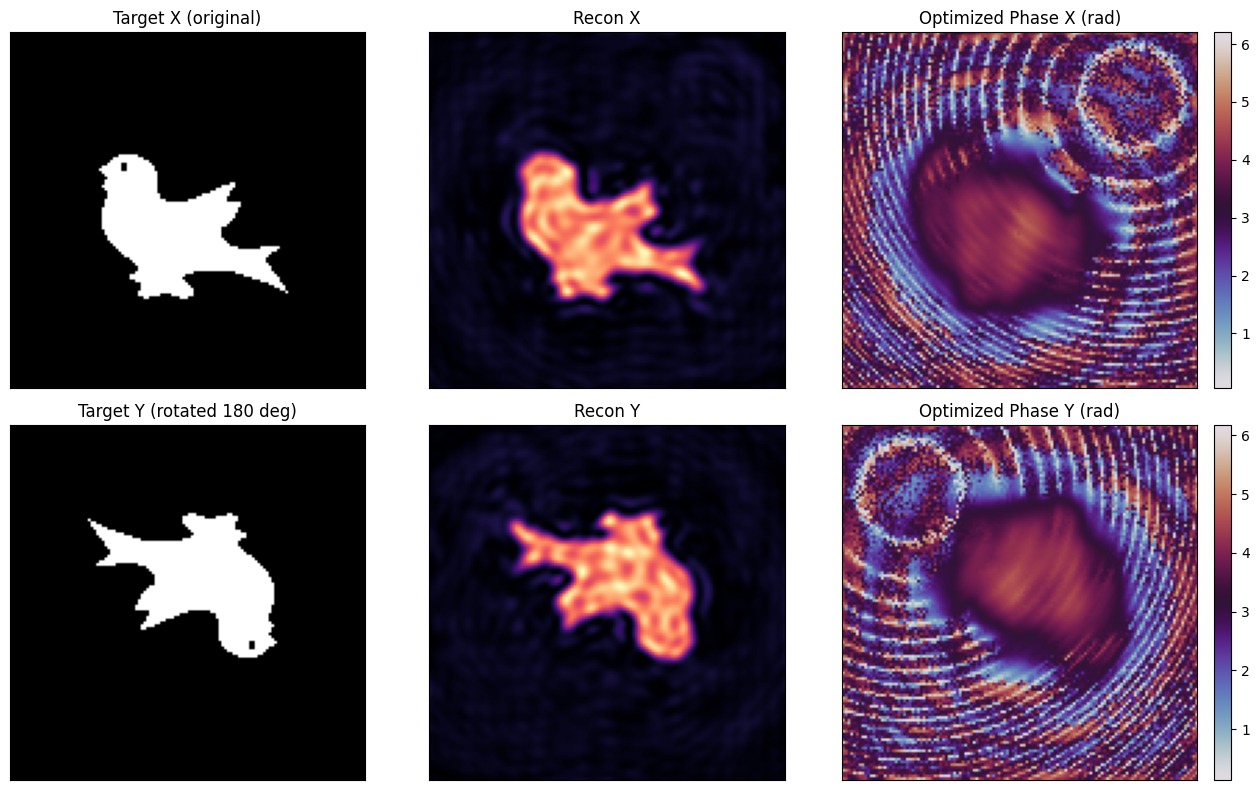

saved: /Users/liam/fouriax/artifacts/holography_polarized_dual_overview.png


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes[0, 0].imshow(np.asarray(target_x), cmap="gray", vmin=0.0, vmax=1.0)
axes[0, 0].set_title("Target X (original)")
axes[0, 1].imshow(np.asarray(recon_x_norm), cmap="magma", vmin=0.0, vmax=1.0)
axes[0, 1].set_title("Recon X")
sx_im = axes[0, 2].imshow(np.asarray(phase_opt[0]), cmap="twilight")
axes[0, 2].set_title("Optimized Phase X (rad)")
plt.colorbar(sx_im, ax=axes[0, 2], fraction=0.046, pad=0.04)
axes[1, 0].imshow(np.asarray(target_y), cmap="gray", vmin=0.0, vmax=1.0)
axes[1, 0].set_title("Target Y (rotated 180 deg)")
axes[1, 1].imshow(np.asarray(recon_y_norm), cmap="magma", vmin=0.0, vmax=1.0)
axes[1, 1].set_title("Recon Y")
sy_im = axes[1, 2].imshow(np.asarray(phase_opt[1]), cmap="twilight")
axes[1, 2].set_title("Optimized Phase Y (rad)")
plt.colorbar(sy_im, ax=axes[1, 2], fraction=0.046, pad=0.04)
for ax in axes.flatten():
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
plot_path = ARTIFACTS_DIR / "holography_polarized_dual_overview.png"
fig.savefig(plot_path, dpi=160)
plt.show()
plt.close(fig)
print(f"saved: {plot_path}")
